# Entrenamiento de Modelo ST-GCN para Reconocimiento de Gestos

Este notebook realiza el entrenamiento del modelo **Spatio-Temporal Graph Convolutional Network (ST-GCN)** utilizando el dataset balanceado y enriquecido generado en el flujo anterior.

### Entradas requeridas:
- Manifiesto unificado: `output/train_manifest_stgcn_secuencias.csv`
- Directorio de secuencias: `data/processed/secuencias_stgcn/` (archivos .npy de shape [16, 21, 3])

In [1]:
import os
import sys
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from datetime import datetime

# Asegurar que el directorio raiz esta en el path para importar src
ROOT_DIR = Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.stgcn.stgcn_model import RealSTGCN
from src.stgcn.hand_graph import build_adjacency_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cu130
Device: cpu


## 1. Configuración de rutas y parámetros

In [2]:
CONFIG = {
    "MANIFEST": "output/train_manifest_stgcn_secuencias.csv",
    "SECUENCIAS_DIR": "data/processed/secuencias_stgcn",
    "MODEL_OUTPUT": "output/models/stgcn_gesture_model_best.pth",
    "MP_TASK_MODEL": "models/hand_landmarker.task",
    "BATCH_SIZE": 32,
    "EPOCHS": 15,
    "LR": 0.001,
    "SEED": 42
}

Path("output/models").mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

## 2. Inspección del dataset balanceado

In [3]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(CONFIG["MANIFEST"])

# 1. Exclusión de bad_pose
initial_count = len(df)
df = df[df['quality_flag'] != 'excluded'].copy()
print(f"Muestras excluidas por calidad: {initial_count - len(df)}")

df['label'] = df['label'].fillna('unknown').astype(str)

# 2. Configurar Label Encoder
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])
unique_labels = le.classes_.tolist()
label_to_idx = {name: i for i, name in enumerate(unique_labels)}
idx_to_label = {i: name for name, i in label_to_idx.items()}

# 3. Calcular pesos para balanceo de clases
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label_idx']),
    y=df['label_idx']
)
weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Total de secuencias efectivas: {len(df)}")
print(f"Clases detectadas ({len(unique_labels)}): {unique_labels}")

# Split Train/Val (80/20)
train_df = df.sample(frac=0.8, random_state=CONFIG["SEED"])
val_df = df.drop(train_df.index)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

Muestras excluidas por calidad: 105
Total de secuencias efectivas: 18489
Clases detectadas (21): ['call', 'dislike', 'fist', 'four', 'hand', 'like', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted', 'unknown']
Train samples: 14791 | Val samples: 3698


## 3. Inicialización del Modelo

In [4]:
adj = build_adjacency_matrix().to(device)

model = RealSTGCN(
    num_classes=len(unique_labels),
    adjacency=adj,
    in_channels=3,
    dropout=0.3
).to(device)

print("Modelo ST-GCN con Atención Espacial inicializado.")

Modelo ST-GCN con Atención Espacial inicializado.


## 4. Cargar Modelo Entrenado (Opcional)

Ejecuta esta celda si ya tienes un modelo guardado y quieres saltarte el entrenamiento.

In [5]:
if Path(CONFIG["MODEL_OUTPUT"]).exists():
    model.load_state_dict(torch.load(CONFIG["MODEL_OUTPUT"], map_location=device))
    print(f"✅ Modelo cargado correctamente desde: {CONFIG['MODEL_OUTPUT']}")
else:
    print("⚠️ No se encontró ningún modelo guardado. Debes proceder al entrenamiento.")

✅ Modelo cargado correctamente desde: output/models/stgcn_gesture_model_best.pth


## 5. Entrenamiento

Salta esta sección si ya cargaste el modelo en el paso anterior.

In [6]:
class STGCNDataset(Dataset):
    def __init__(self, manifest_df, base_dir, label_map, augment=False):
        self.df = manifest_df
        self.base_dir = Path(base_dir)
        self.label_map = label_map
        self.augment = augment
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(row['path_secuencia'])
        if not path.exists(): path = self.base_dir / path.name
        
        seq = np.load(path).astype(np.float32) # (16, 21, 3)
        
        # 4. Augmentation: Node Dropping (p=0.1)
        if self.augment:
            num_nodes = seq.shape[1]
            mask = np.random.rand(num_nodes) > 0.1
            seq[:, ~mask, :] = 0.0
            
        x = torch.from_numpy(np.transpose(seq, (2, 0, 1))).float() # (3, 16, 21)
        y = torch.tensor(self.label_map[str(row['label'])], dtype=torch.long)
        return x, y

train_ds = STGCNDataset(train_df, CONFIG["SECUENCIAS_DIR"], label_to_idx, augment=True)
val_ds = STGCNDataset(val_df, CONFIG["SECUENCIAS_DIR"], label_to_idx, augment=False)
train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=CONFIG["LR"])

history = {'train_loss': [], 'val_acc': []}
best_acc = 0.0
for epoch in range(CONFIG['EPOCHS']):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0); correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total; train_loss = running_loss / len(train_loader)
    history['train_loss'].append(train_loss); history['val_acc'].append(val_acc)
    print(f"Epoch [{epoch+1}/{CONFIG['EPOCHS']}] - Loss: {train_loss:.4f} - Val Acc: {val_acc:.2f}%")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CONFIG["MODEL_OUTPUT"])
        print(f"  --> Guardado mejor modelo ({best_acc:.2f}%)")

Epoch [1/15] - Loss: 3.0438 - Val Acc: 18.82%
  --> Guardado mejor modelo (18.82%)
Epoch [2/15] - Loss: 3.0444 - Val Acc: 12.66%
Epoch [3/15] - Loss: 3.0426 - Val Acc: 11.84%
Epoch [4/15] - Loss: 3.0420 - Val Acc: 5.00%
Epoch [5/15] - Loss: 3.0418 - Val Acc: 9.63%


KeyboardInterrupt: 

## 6. Demo de Inferencia y Visualización de Atención

--- Iniciando demo con 5 imágenes --- 



W0000 00:00:1776698387.710085  224671 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698387.720892  224671 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698387.755827  224679 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698387.765316  224679 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698387.796356  224690 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698387.805795  224690 inference_feedback_manager.cc:114] Feedback manager 

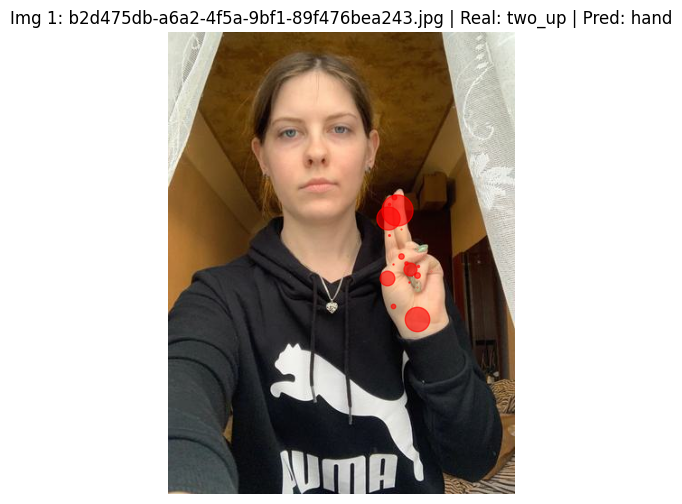

W0000 00:00:1776698388.067496  224706 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.077103  224711 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


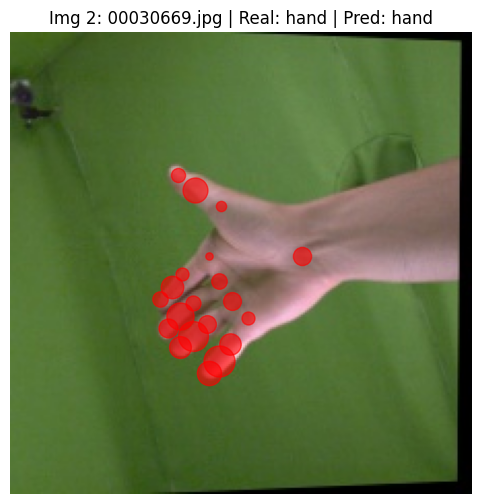

W0000 00:00:1776698388.277947  224714 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.286025  224717 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


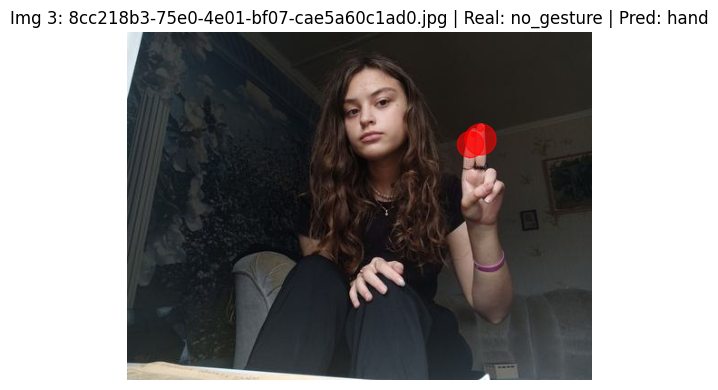

W0000 00:00:1776698388.474780  224723 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.484597  224728 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


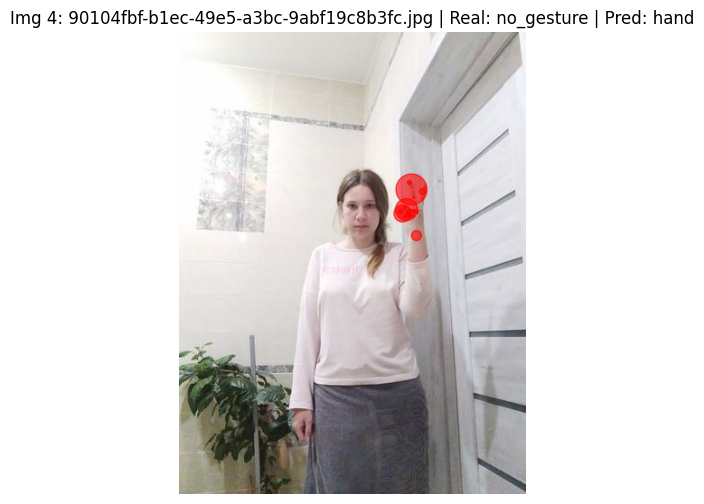

W0000 00:00:1776698388.698149  224733 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.709040  224733 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.736422  224743 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776698388.747582  224743 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


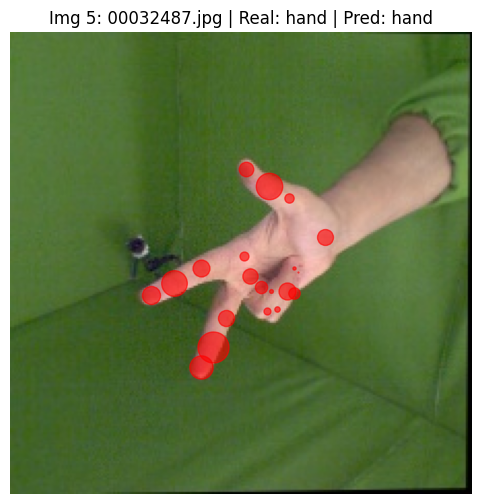

In [ ]:
def get_hand_landmarks(image_path):
    base_options = python.BaseOptions(model_asset_path=CONFIG['MP_TASK_MODEL'])
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
    with vision.HandLandmarker.create_from_options(options) as landmarker:
        image = mp.Image.create_from_file(str(image_path))
        res = landmarker.detect(image)
        if not res.hand_landmarks: return None
        return np.array([[lm.x, lm.y, lm.z] for lm in res.hand_landmarks[0]])

def plot_attention(image_path, landmarks, weights, title=""):
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    plt.figure(figsize=(6, 6)); plt.imshow(image)
    w_norm = (weights.cpu().numpy() - weights.min().item()) / (weights.max().item() - weights.min().item() + 1e-6)
    for lm, weight in zip(landmarks, w_norm):
        plt.scatter(int(lm[0] * w), int(lm[1] * h), s=weight * 500, c='red', alpha=0.6)
    plt.title(title); plt.axis('off'); plt.show()

col_path = 'path' if 'path' in val_df.columns else 'image_path'
found_count = 0
max_attempts = 100

print(f"--- Iniciando demo con 5 imágenes --- \n")
for i in range(max_attempts):
    sample = val_df.sample(1).iloc[0]
    image_path = Path(sample[col_path])
    if image_path.exists():
        landmarks = get_hand_landmarks(image_path)
        if landmarks is not None:
            seq = np.tile(landmarks, (16, 1, 1)).astype(np.float32)
            x = torch.from_numpy(np.transpose(seq, (2, 0, 1))).unsqueeze(0).to(device)
            model.eval()
            with torch.no_grad():
                logits, attention = model(x)
                prediction = idx_to_label[torch.argmax(logits, dim=1).item()]
            
            msg = f"Img {found_count+1}: {image_path.name} | Real: {sample['label']} | Pred: {prediction}"
            plot_attention(image_path, landmarks, attention[0], title=msg)
            found_count += 1
            
    if found_count >= 5: break